# Data Cleaning & Scraping

### Importing the dataset

In [73]:
import os
print(os.getcwd())


c:\Users\Israa Atike\Documents\Project\thesis-project-israa-atike\scripts


In [74]:
import pandas as pd
import numpy as np
# Load dataset
data = pd.read_csv(r'c:\Users\Israa Atike\Documents\Project\thesis-project-israa-atike\data\diabetic_data.csv')

data.head()
data.info()
data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,MC,?,51,0,16,0,0,0,250.13,291,458,9,NaN,>8,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,MC,?,33,3,18,0,0,1,560,276,787,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,MC,?,53,0,9,1,0,0,38,590,296,13,NaN,NaN,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,MC,Surgery-General,45,2,21,0,0,1,996,285,998,9,NaN,NaN,No,No,No,No,No,No,Steady,No,No,Steady,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO


### Handling missing values

We will first start by looking for columns that are highly incomplete in order to drop them, and after that we will start cleaning variable by variable to keep the notebook organised

In [75]:
# Replace '?' with NaN since a loyt of missing values are represented by '?'
data.replace('?', np.nan, inplace=True)

# Check missing values per column
missing_values = data.isna().sum()

print(missing_values)

missing_percentage = (data.isna().sum() / len(data)) * 100

# Display percentages sorted descending
missing_percentage = missing_percentage.sort_values(ascending=False)
print(missing_percentage)

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

Let's check the columns with more than 80% of missing data first.

For the column weight it has too many missing values almost 97% so we decided to drop it

In [76]:
# Drop the 'weight' column
data.drop(columns=['weight'], inplace=True)
data.info()
print(data.columns)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 49 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   admission_type_id         101766 non-null  int64 
 6   discharge_disposition_id  101766 non-null  int64 
 7   admission_source_id       101766 non-null  int64 
 8   time_in_hospital          101766 non-null  int64 
 9   payer_code                61510 non-null   object
 10  medical_specialty         51817 non-null   object
 11  num_lab_procedures        101766 non-null  int64 
 12  num_procedures            101766 non-null  int64 
 13  num_medications           101766 non-null  int64 
 14  numb

In [77]:
# Count occurrences for A1Cresult
a1c_counts = data['A1Cresult'].value_counts(dropna=False)
print("A1Cresult value counts:")
print(a1c_counts)


# Count occurrences for max_glu_serum
glu_counts = data['max_glu_serum'].value_counts(dropna=False)
print("max_glu_serum value counts:")
print(glu_counts)

A1Cresult value counts:
A1Cresult
NaN     84748
>8       8216
Norm     4990
>7       3812
Name: count, dtype: int64
max_glu_serum value counts:
max_glu_serum
NaN     96420
Norm     2597
>200     1485
>300     1264
Name: count, dtype: int64


After checking the two columns A1Cresult and max_glu_serum, we discovered that they both have a column called "None" which Pandas treats as a missing value despite the fact that it actually means that the test was not measured for that patient, thus we decide to keep both these columns and change the NAN values back into their actual values which IS "None" or "Not measured"

In [78]:
# Replace NaN with 'Not measured' in A1Cresult and max_glu_serum
data['A1Cresult'].fillna('Not measured', inplace=True)
data['max_glu_serum'].fillna('Not measured', inplace=True)

print(data['A1Cresult'].value_counts())
print(data['max_glu_serum'].value_counts())


A1Cresult
Not measured    84748
>8               8216
Norm             4990
>7               3812
Name: count, dtype: int64
max_glu_serum
Not measured    96420
Norm             2597
>200             1485
>300             1264
Name: count, dtype: int64


C:\Users\Israa Atike\AppData\Local\Temp\ipykernel_33028\3687043486.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['A1Cresult'].fillna('Not measured', inplace=True)
C:\Users\Israa Atike\AppData\Local\Temp\ipykernel_33028\3687043486.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

Now let's check the column that have less than 50% of missing values

In [79]:
medical_specialty_Counts = data['medical_specialty'].value_counts(dropna=False)
print("medical_specialty value counts:")
print(medical_specialty_Counts)

payer_code_counts = data['payer_code'].value_counts(dropna=False)
print("payer_code value counts:")
print(payer_code_counts)

medical_specialty value counts:
medical_specialty
NaN                              49949
InternalMedicine                 14635
Emergency/Trauma                  7565
Family/GeneralPractice            7440
Cardiology                        5352
                                 ...  
SportsMedicine                       1
Speech                               1
Perinatology                         1
Neurophysiology                      1
Pediatrics-InfectiousDiseases        1
Name: count, Length: 73, dtype: int64
payer_code value counts:
payer_code
NaN    40256
MC     32439
HM      6274
SP      5007
BC      4655
MD      3532
CP      2533
UN      2448
CM      1937
OG      1033
PO       592
DM       549
CH       146
WC       135
OT        95
MP        79
SI        55
FR         1
Name: count, dtype: int64


After investigating the column 'medical speciality' we decided to drop this column as it has high number of missing values of 50% as
well as it is very granular and have too many values.

As for payer_code column since almost 40% of the data is missing we  drop this column, and because of the fact that it has a low importance to this data.

In [80]:
# remove payer_code and medical_specialty
# due to high missing values and low importance
data.drop(columns=['payer_code', 'medical_specialty'], inplace=True)

Now lets check the 4 last columns with missing values, 'race', 'diag_3', 'diag_2' and 'diag_1'

In [81]:
race_counts = data['race'].value_counts(dropna=False)
print("race value counts:")
print(race_counts)

diag_3_counts = data['diag_3'].value_counts(dropna=False)
print("diag_3 value counts:")
print(diag_3_counts)
diag_2_counts = data['diag_2'].value_counts(dropna=False)
print("diag_2 value counts:")
print(diag_2_counts)
diag_1_counts = data['diag_1'].value_counts(dropna=False)
print("diag_1 value counts:")
print(diag_1_counts)



race value counts:
race
Caucasian          76099
AfricanAmerican    19210
NaN                 2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64
diag_3 value counts:
diag_3
250     11555
401      8289
276      5175
428      4577
427      3955
        ...  
657         1
684         1
603         1
E826        1
971         1
Name: count, Length: 790, dtype: int64
diag_2 value counts:
diag_2
276     6752
428     6662
250     6071
427     5036
401     3736
        ... 
E918       1
46         1
V13        1
E850       1
927        1
Name: count, Length: 749, dtype: int64
diag_1 value counts:
diag_1
428    6862
414    6581
786    4016
410    3614
486    3508
       ... 
373       1
314       1
684       1
217       1
V51       1
Name: count, Length: 717, dtype: int64


I have decided to drop the missing values since the total number of rows I would drop is at most 4,075 (2273 + 1423 + 358 + 21), which is less than 4% of my dataset. Losing <4% of my data is a very small price to pay for having a 100% complete dataset for these important features.

In [82]:
data.dropna(subset=['race', 'diag_1', 'diag_2', 'diag_3'], inplace=True)
print(f"Remaining rows: {len(data)}")


Remaining rows: 98053


As I predicted above I only lost 3714 rows since some missing values overlap that is why it did not reach 4075 and now we are left with 98053 rows which is a very good numebrs of rows.

In [83]:
# cghecking if my dataset has any missing values left
print(data.isna().sum())

encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose                    0
miglitol  

### Dropping unnecessary columns

Finally we will also drop 'encounter_id' because it is just an id and is not meaningful to neither the visualisations or the modelling, but we will keep 'patient_nbr' for now because it can be helpful for the visualisation but we will remove it later because it will be meanginless to the modelling

In [84]:
# dropping encounter_id since it is not meaningful to neither the visualisations or the modelling
data.drop(columns=['encounter_id'], inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98053 entries, 1 to 101765
Data columns (total 46 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   patient_nbr               98053 non-null  int64 
 1   race                      98053 non-null  object
 2   gender                    98053 non-null  object
 3   age                       98053 non-null  object
 4   admission_type_id         98053 non-null  int64 
 5   discharge_disposition_id  98053 non-null  int64 
 6   admission_source_id       98053 non-null  int64 
 7   time_in_hospital          98053 non-null  int64 
 8   num_lab_procedures        98053 non-null  int64 
 9   num_procedures            98053 non-null  int64 
 10  num_medications           98053 non-null  int64 
 11  number_outpatient         98053 non-null  int64 
 12  number_emergency          98053 non-null  int64 
 13  number_inpatient          98053 non-null  int64 
 14  diag_1                    

In [85]:
data.head()

,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
1,55629189,Caucasian,Female,[10-20),1,1,7,3,59,0,18,0,0,0,276,250.01,255,9,Not measured,Not measured,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,2,0,1,648,250,V27,6,Not measured,Not measured,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,82442376,Caucasian,Male,[30-40),1,1,7,2,44,1,16,0,0,0,8,250.43,403,7,Not measured,Not measured,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,42519267,Caucasian,Male,[40-50),1,1,7,1,51,0,8,0,0,0,197,157,250,5,Not measured,Not measured,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,82637451,Caucasian,Male,[50-60),2,1,2,3,31,6,16,0,0,0,414,411,250,9,Not measured,Not measured,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,>30


### Fixing Data Types

In [86]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98053 entries, 1 to 101765
Data columns (total 46 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   patient_nbr               98053 non-null  int64 
 1   race                      98053 non-null  object
 2   gender                    98053 non-null  object
 3   age                       98053 non-null  object
 4   admission_type_id         98053 non-null  int64 
 5   discharge_disposition_id  98053 non-null  int64 
 6   admission_source_id       98053 non-null  int64 
 7   time_in_hospital          98053 non-null  int64 
 8   num_lab_procedures        98053 non-null  int64 
 9   num_procedures            98053 non-null  int64 
 10  num_medications           98053 non-null  int64 
 11  number_outpatient         98053 non-null  int64 
 12  number_emergency          98053 non-null  int64 
 13  number_inpatient          98053 non-null  int64 
 14  diag_1                    

In [87]:
# Converting data types
# ID features

data['patient_nbr'] = data['patient_nbr'].astype(str)

# Categorical features
categorical_cols = [
    'race', 'gender', 'age',  # demographic
    'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
    'diag_1', 'diag_2', 'diag_3',
    'max_glu_serum', 'A1Cresult', 
    # drug features
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
    'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
    'tolazamide', 'insulin', 'examide', 'citoglipton',
    'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone',
    'change', 'diabetesMed', 'readmitted'
]
data[categorical_cols] = data[categorical_cols].astype('category')


# Numeric features
numeric_cols = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses'
]
data[numeric_cols] = data[numeric_cols].apply(pd.to_numeric, errors='coerce')

#  Age → keep as readable bins for Power BI and visualisations
# Already in format '[0-10)', '[10-20)',
data['age'] = data['age'].astype('category')


print(data.dtypes)




patient_nbr                   object
race                        category
gender                      category
age                         category
admission_type_id           category
discharge_disposition_id    category
admission_source_id         category
time_in_hospital               int64
num_lab_procedures             int64
num_procedures                 int64
num_medications                int64
number_outpatient              int64
number_emergency               int64
number_inpatient               int64
diag_1                      category
diag_2                      category
diag_3                      category
number_diagnoses               int64
max_glu_serum               category
A1Cresult                   category
metformin                   category
repaglinide                 category
nateglinide                 category
chlorpropamide              category
glimepiride                 category
acetohexamide               category
glipizide                   category
g

In [88]:
# missing values check
print(data.isna().sum())

patient_nbr                 0
race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose                    0
miglitol                    0
troglitazo

All missing values have been taken care of, now we will move on to the next part which is cleaning column by column, up until now we will be keeping the orignial categories since we will need them for the EDA especially the visualisations that I plan to build using Power BI, and after the visualisation we will make sure to encode them to make them suitable for modelling.

### Handling Inconsistent Values column by column: keeping all the original categories so far in order to make it easier while building visualiations

In [89]:
data.head()

,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
1,55629189,Caucasian,Female,[10-20),1,1,7,3,59,0,18,0,0,0,276,250.01,255,9,Not measured,Not measured,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,2,0,1,648,250,V27,6,Not measured,Not measured,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,82442376,Caucasian,Male,[30-40),1,1,7,2,44,1,16,0,0,0,8,250.43,403,7,Not measured,Not measured,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,42519267,Caucasian,Male,[40-50),1,1,7,1,51,0,8,0,0,0,197,157,250,5,Not measured,Not measured,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,82637451,Caucasian,Male,[50-60),2,1,2,3,31,6,16,0,0,0,414,411,250,9,Not measured,Not measured,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,>30


### Cleaning column by column, including inconsistencies for categorical variables and outliers for numerical variables

In this section we will be cleaning the dataset column by column, preparing the data for EDA, by fixing all inconsistencies of the data.

Race Column:

In [90]:
data['race'].value_counts()
# change "AfricanAmerican" to "African American"
data['race'] = data['race'].replace('AfricanAmerican', 'African American')
# verify changes
data['race'].value_counts()

C:\Users\Israa Atike\AppData\Local\Temp\ipykernel_33028\1708906332.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  data['race'] = data['race'].replace('AfricanAmerican', 'African American')


race
Caucasian           75079
African American    18881
Hispanic             1984
Other                1484
Asian                 625
Name: count, dtype: int64

Gender Column:

In [91]:
data['gender'].value_counts()

# Drop rows with 'Unknown/Invalid'
data = data[data['gender'] != 'Unknown/Invalid']

# Remove the unused category
data['gender'] = data['gender'].cat.remove_categories(['Unknown/Invalid'])

# Verify
print(data['gender'].value_counts())
print(data['gender'].cat.categories)


gender
Female    52833
Male      45219
Name: count, dtype: int64
Index(['Female', 'Male'], dtype='object')


C:\Users\Israa Atike\AppData\Local\Temp\ipykernel_33028\4170952197.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['gender'] = data['gender'].cat.remove_categories(['Unknown/Invalid'])


For this column i dropped the row with 'Unknown/Invalid' since it is only one row and will not affect the rest of my data.

Age Column:

In [92]:
data['age'].unique()
# checcking numbers of entries per age group    
data['age'].value_counts()

age
[70-80)     25305
[60-70)     21809
[80-90)     16702
[50-60)     16697
[40-50)      9265
[30-40)      3548
[90-100)     2717
[20-30)      1478
[10-20)       466
[0-10)         65
Name: count, dtype: int64

admission_type_id, discharge_disposition_id, admission_source_id columns:

In [93]:
# checkinf unique categories in admission_type_id, discharge_disposition_id, admission_source_id columns
data['admission_type_id'].unique()
data['discharge_disposition_id'].unique()
data['admission_source_id'].unique()

# checking number of enetries per category in admission_type_id
data['admission_type_id'].value_counts()

# checking number of enetries per category in discharge_disposition_id
data['discharge_disposition_id'].value_counts()

# checking number of enetries per category in admission_source_id
data['admission_source_id'].value_counts()

admission_source_id
7     55951
1     28355
17     6602
4      2945
6      1893
2      1031
5       846
3       179
20      160
9        49
8        15
22       12
10        7
11        2
14        2
25        2
13        1
Name: count, dtype: int64

Time in hospital column:


Summary Statistics:
count    98052.000000
mean         4.422011
std          2.993070
min          1.000000
25%          2.000000
50%          4.000000
75%          6.000000
max         14.000000
Name: time_in_hospital, dtype: float64


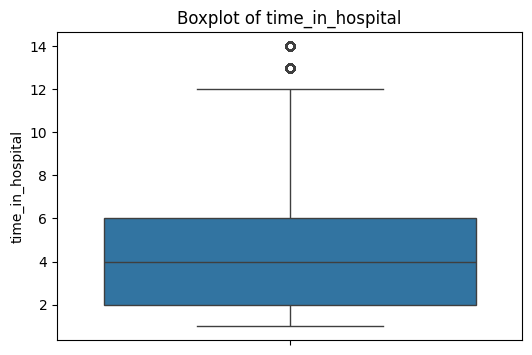

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# cehcking time_in_hospital entries
data['time_in_hospital'].value_counts()


# Summary statistics
print("\nSummary Statistics:")
print(data['time_in_hospital'].describe())

# Boxplot to visualize outliers
plt.figure(figsize=(6,4))
sns.boxplot(y=data['time_in_hospital'])
plt.title("Boxplot of time_in_hospital")
plt.show()

Outliers look normal and reasonable so we will be moving foraward

num_lab_procedures, num_procedures, num_medications, number_outpatient, number_emergency, number_inpatient Columns:

 Summary Statistic
       num_lab_procedures  num_procedures  num_medications  number_outpatient  number_emergency  number_inpatient
count        98052.000000    98052.000000     98052.000000       98052.000000      98052.000000      98052.000000
mean            43.148462        1.350712        16.119590           0.376382          0.202464          0.646871
std             19.711757        1.708475         8.108496           1.283365          0.942897          1.271025
min              1.000000        0.000000         1.000000           0.000000          0.000000          0.000000
25%             31.000000        0.000000        11.000000           0.000000          0.000000          0.000000
50%             44.000000        1.000000        15.000000           0.000000          0.000000          0.000000
75%             57.000000        2.000000        20.000000           0.000000          0.000000          1.000000
max            132.000000        6.000000        81.000000          4

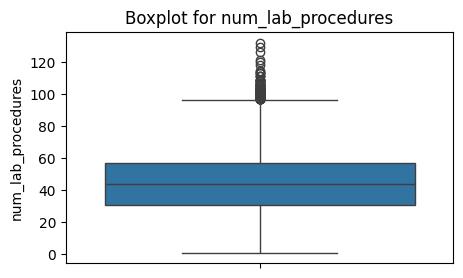

num_procedures: 4811 outliers


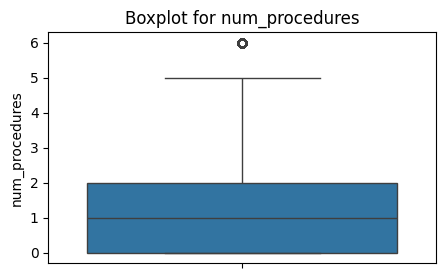

num_medications: 3306 outliers


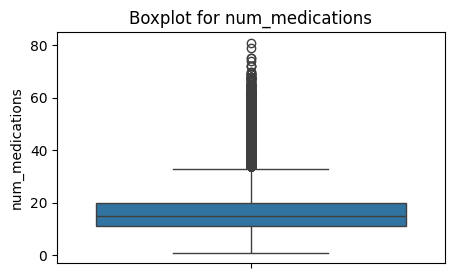

number_outpatient: 16373 outliers


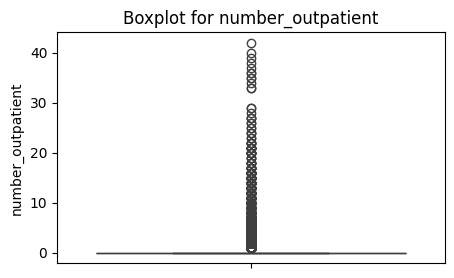

number_emergency: 11207 outliers


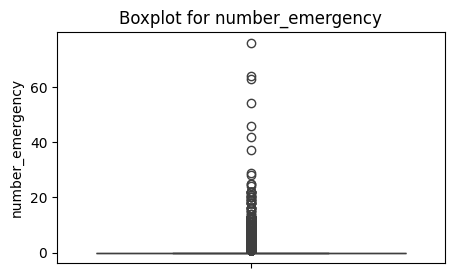

number_inpatient: 6931 outliers


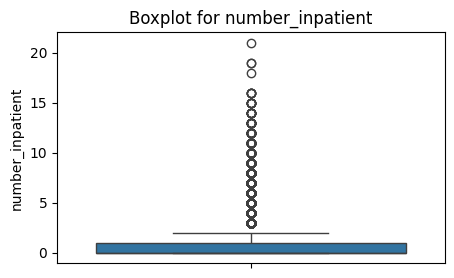

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Columns to check
num_cols = [
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient"
]

# Summary statistics
print(" Summary Statistic")
print(data[num_cols].describe())

#  Detect outliers using IQR method and visualize with boxplots
for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")
    
    # Boxplot
    plt.figure(figsize=(5,3))
    sns.boxplot(y=data[col])
    plt.title(f"Boxplot for {col}")
    plt.show()


We decided not to remove outliers because they represent plausible real-world cases, such as patients with many lab tests or visits. Removing them would distort the natural distribution of the data and could lead to loss of important information. Instead, for modeling, extreme values can be mitigated through capping or transformation without deleting any rows.

diag_1, diag_2, diag_3 columns:

In [96]:
# Function to map ICD-9 codes to 9 categories
def map_icd9_to_category(code):
    code = str(code).strip()  # remove whitespace
    
    # Handle E/V codes
    if code.upper().startswith('E') or code.upper().startswith('V'):
        return 'OTHER'
    
    # Convert to float for numeric ranges
    try:
        code_num = float(code)
    except:
        return 'OTHER'
    
    # Map to 9 categories based on ICD-9 ranges
    if 250 <= code_num < 252:
        return 'DIABETES'
    elif 390 <= code_num < 460 or code_num == 785:
        return 'CIRCULATORY'
    elif 460 <= code_num < 520 or code_num == 786:
        return 'RESPIRATORY'
    elif 520 <= code_num < 580 or code_num == 787:
        return 'DIGESTIVE'
    elif 580 <= code_num < 630 or code_num == 788:
        return 'GENITOURINARY'
    elif 800 <= code_num <= 999:
        return 'INJURY'
    elif 710 <= code_num < 740:
        return 'MUSCULOSKELETAL'
    elif 140 <= code_num < 240:
        return 'NEOPLASMS'
    else:
        return 'OTHER'

# Apply mapping to diag_1, diag_2, diag_3
for col in ['diag_1', 'diag_2', 'diag_3']:
    data[col] = data[col].apply(map_icd9_to_category)

# Quick check
for col in ['diag_1', 'diag_2', 'diag_3']:
    print(f"{col} value counts:\n", data[col].value_counts(), "\n")


diag_1 value counts:
 diag_1
CIRCULATORY        29629
OTHER              17528
RESPIRATORY        13993
DIGESTIVE           9187
DIABETES            7978
INJURY              6703
GENITOURINARY       4983
MUSCULOSKELETAL     4739
NEOPLASMS           3312
Name: count, dtype: int64 

diag_2 value counts:
 diag_2
CIRCULATORY        31103
OTHER              25657
DIABETES           11872
RESPIRATORY        10637
GENITOURINARY       8203
DIGESTIVE           4049
NEOPLASMS           2493
INJURY              2328
MUSCULOSKELETAL     1710
Name: count, dtype: int64 

diag_3 value counts:
 diag_3
CIRCULATORY        29631
OTHER              28569
DIABETES           16702
RESPIRATORY         7199
GENITOURINARY       6527
DIGESTIVE           3852
INJURY              1890
MUSCULOSKELETAL     1862
NEOPLASMS           1820
Name: count, dtype: int64 



C:\Users\Israa Atike\AppData\Local\Temp\ipykernel_33028\3810285598.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[col] = data[col].apply(map_icd9_to_category)
C:\Users\Israa Atike\AppData\Local\Temp\ipykernel_33028\3810285598.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[col] = data[col].apply(map_icd9_to_category)
C:\Users\Israa Atike\AppData\Local\Temp\ipykernel_33028\3810285598.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

The three diagnosis variables, diag1, diag2, and diag_3, originally contained about 700 different ICD-9 codes each. We chose to do a preprocess to simplify the data: first, missing values were already treated, so there was no imputation step needed. All of the ICD-9 codes were mapped to one of nine health categories: Circulatory, Respiratory, Digestive, Diabetes, Injury, Musculoskeletal, Genitourinary, Neoplasms, and Other. ICD-9 codes which began with "E" or "V" were assigned to the "Other" category. This helps to simplify the original ICD-9 codes and makes the data easier to explore and model using machine learning algorithms.

number_diagnoses column:


Summary Statistics:
count    98052.000000
mean         7.512096
std          1.832472
min          3.000000
25%          6.000000
50%          8.000000
75%          9.000000
max         16.000000
Name: number_diagnoses, dtype: float64


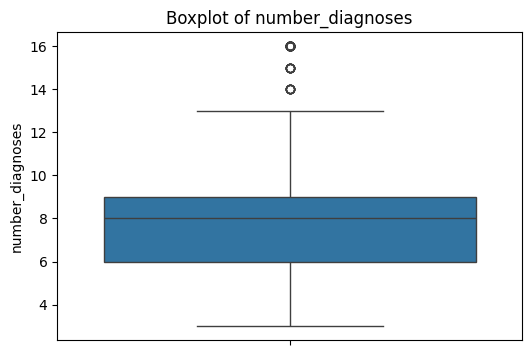

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# cehcking number_diagnoses entries
data['number_diagnoses'].value_counts()


# Summary statistics
print("\nSummary Statistics:")
print(data['number_diagnoses'].describe())

# Boxplot to visualize outliers
plt.figure(figsize=(6,4))
sns.boxplot(y=data['number_diagnoses'])
plt.title("Boxplot of number_diagnoses")
plt.show()

Outliers looking reasonable thus we move on.

The rest of the categorical columns:

In [98]:
import pandas as pd

# List of categorical columns
cat_cols = [
    'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 
    'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 
    'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 
    'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 
    'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 
    'diabetesMed', 'readmitted'
]

# Function to clean categorical values (no missing value handling)
def clean_categorical(val):
    val_str = str(val).strip().upper()  # remove whitespace and convert to uppercase
    return val_str

# Dictionary to store unique values for each column
unique_values_dict = {}

# Apply cleaning and store unique values
for col in cat_cols:
    data[col ] = data[col].apply(clean_categorical)
    unique_values_dict[col] = data[col].unique()

# Display unique values for each column
for col, values in unique_values_dict.items():
    print(f"{col}: {len(values)} unique values -> {list(values)}\n")


max_glu_serum: 4 unique values -> ['NOT MEASURED', '>300', 'NORM', '>200']

A1Cresult: 4 unique values -> ['NOT MEASURED', '>7', '>8', 'NORM']

metformin: 4 unique values -> ['NO', 'STEADY', 'UP', 'DOWN']

repaglinide: 4 unique values -> ['NO', 'UP', 'STEADY', 'DOWN']

nateglinide: 4 unique values -> ['NO', 'STEADY', 'DOWN', 'UP']

chlorpropamide: 4 unique values -> ['NO', 'STEADY', 'DOWN', 'UP']

glimepiride: 4 unique values -> ['NO', 'STEADY', 'DOWN', 'UP']

acetohexamide: 2 unique values -> ['NO', 'STEADY']

glipizide: 4 unique values -> ['NO', 'STEADY', 'UP', 'DOWN']

glyburide: 4 unique values -> ['NO', 'STEADY', 'UP', 'DOWN']

tolbutamide: 2 unique values -> ['NO', 'STEADY']

pioglitazone: 4 unique values -> ['NO', 'STEADY', 'UP', 'DOWN']

rosiglitazone: 4 unique values -> ['NO', 'STEADY', 'UP', 'DOWN']

acarbose: 4 unique values -> ['NO', 'STEADY', 'UP', 'DOWN']

miglitol: 4 unique values -> ['NO', 'STEADY', 'DOWN', 'UP']

troglitazone: 2 unique values -> ['NO', 'STEADY']

tolaz

C:\Users\Israa Atike\AppData\Local\Temp\ipykernel_33028\697592739.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[col ] = data[col].apply(clean_categorical)
C:\Users\Israa Atike\AppData\Local\Temp\ipykernel_33028\697592739.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[col ] = data[col].apply(clean_categorical)
C:\Users\Israa Atike\AppData\Local\Temp\ipykernel_33028\697592739.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .lo

In [99]:
# Replace 'CH' with 'YES' in change column
data['change'] = data['change'].replace({'CH': 'YES'})
print(data['change'].unique())


['YES', 'NO']
Categories (2, object): ['YES', 'NO']


C:\Users\Israa Atike\AppData\Local\Temp\ipykernel_33028\643310092.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  data['change'] = data['change'].replace({'CH': 'YES'})
C:\Users\Israa Atike\AppData\Local\Temp\ipykernel_33028\643310092.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['change'] = data['change'].replace({'CH': 'YES'})


In [100]:
# Drop  columns with one unique value only (zero variance)
cols_to_drop = ['examide', 'citoglipton', 'metformin-rosiglitazone', 'glimepiride-pioglitazone']
data = data.drop(columns=cols_to_drop)

# Check remaining columns
print("Remaining columns:")
print(data.columns)


Remaining columns:
Index(['patient_nbr', 'race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide',
       'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin',
       'glyburide-metformin', 'glipizide-metformin', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')


We will drop the column with one unique value only since Predictive models rely on variation in features to learn patterns; these columns cannot help the model distinguish between outcomes and keeping them would add unnecessary noise and slightly increase memory usage without benefit.

### Handling Duplicates:

In [101]:
import pandas as pd

subset_cols = ['patient_nbr']  

# Find duplicates based on patient ID
duplicate_patients = data[data.duplicated(subset=subset_cols, keep=False)]

print(f"Number of duplicate patient entries: {duplicate_patients.shape[0]}")

# Show sample duplicate entries
if not duplicate_patients.empty:
    print("Sample duplicate entries based on patient ID:")
    print(duplicate_patients.head())


Number of duplicate patient entries: 45703
Sample duplicate entries based on patient ID:
   patient_nbr       race  gender      age admission_type_id discharge_disposition_id admission_source_id  time_in_hospital  num_lab_procedures  num_procedures  num_medications  number_outpatient  \
12    85504905  Caucasian  Female  [40-50)                 1                        3                   7                 7                  60               0               15                  0   
27   115196778  Caucasian  Female  [50-60)                 1                        1                   1                 2                  25               2               11                  0   
28    41606064  Caucasian    Male  [20-30)                 2                        1                   2                10                  53               0               20                  0   
32    80845353  Caucasian  Female  [70-80)                 1                        1                   7          

In [102]:
# REMOVE DUPLICATE PATIENTS  KEEP FIRST ENCOUNTER ONLY based  on patient_nbr as it is the unique identifier for patients
print(f"Original dataset: {len(data):,} encounters")
print(f"Unique patients: {data['patient_nbr'].nunique():,}")

# Keep only the first encounter per patient
data = data.drop_duplicates(subset=['patient_nbr'], keep='first')

print(f"After removing duplicates: {len(data):,} encounters")
print(f"Removed: {len(data) - len(data):,} duplicate encounters")
print(f"Reduction: {((len(data) - len(data)) / len(data) * 100):.1f}%")
# Verify each patient appears only once
print(f"Unique patients in cleaned data: {data['patient_nbr'].nunique():,}")

Original dataset: 98,052 encounters
Unique patients: 68,629
After removing duplicates: 68,629 encounters
Removed: 0 duplicate encounters
Reduction: 0.0%
Unique patients in cleaned data: 68,629


I removed duplicate patient entries because standard machine learning models like Logistic Regression assume that all data points are independent. If I include the same patient multiple times, their specific health history biases the model. By keeping only the first occurrence, I establish a clean baseline for each patient, prevent data leakage between training and testing sets.

In [103]:
# checking the daata first rows
data.head()


,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,metformin-pioglitazone,change,diabetesMed,readmitted
1,55629189,Caucasian,Female,[10-20),1,1,7,3,59,0,18,0,0,0,OTHER,DIABETES,OTHER,9,NOT MEASURED,NOT MEASURED,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,UP,NO,NO,NO,YES,YES,>30
2,86047875,African American,Female,[20-30),1,1,7,2,11,5,13,2,0,1,OTHER,DIABETES,OTHER,6,NOT MEASURED,NOT MEASURED,NO,NO,NO,NO,NO,NO,STEADY,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,YES,NO
3,82442376,Caucasian,Male,[30-40),1,1,7,2,44,1,16,0,0,0,OTHER,DIABETES,CIRCULATORY,7,NOT MEASURED,NOT MEASURED,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,UP,NO,NO,NO,YES,YES,NO
4,42519267,Caucasian,Male,[40-50),1,1,7,1,51,0,8,0,0,0,NEOPLASMS,NEOPLASMS,DIABETES,5,NOT MEASURED,NOT MEASURED,NO,NO,NO,NO,NO,NO,STEADY,NO,NO,NO,NO,NO,NO,NO,NO,STEADY,NO,NO,NO,YES,YES,NO
5,82637451,Caucasian,Male,[50-60),2,1,2,3,31,6,16,0,0,0,CIRCULATORY,CIRCULATORY,DIABETES,9,NOT MEASURED,NOT MEASURED,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,STEADY,NO,NO,NO,NO,YES,>30


Making sure the types of the variables are correct.

In [104]:
# columns types
print(data.dtypes)



patient_nbr                   object
race                        category
gender                      category
age                         category
admission_type_id           category
discharge_disposition_id    category
admission_source_id         category
time_in_hospital               int64
num_lab_procedures             int64
num_procedures                 int64
num_medications                int64
number_outpatient              int64
number_emergency               int64
number_inpatient               int64
diag_1                        object
diag_2                        object
diag_3                        object
number_diagnoses               int64
max_glu_serum               category
A1Cresult                   category
metformin                   category
repaglinide                 category
nateglinide                 category
chlorpropamide              category
glimepiride                 category
acetohexamide               category
glipizide                   category
g

In [105]:
# Ensure correct data types
data = data.astype({
    'patient_nbr': str,
    'race': str,
    'gender': str,
    'age': str,
    'admission_type_id': str,          
    'discharge_disposition_id': str,    
    'admission_source_id': str,        
    'time_in_hospital': 'int64',
    'num_lab_procedures': 'int64',
    'num_procedures': 'int64',
    'num_medications': 'int64',
    'number_outpatient': 'int64',
    'number_emergency': 'int64',
    'number_inpatient': 'int64',
    'diag_1': str,
    'diag_2': str,
    'diag_3': str,
    'number_diagnoses': 'int64',
    'max_glu_serum': str,
    'A1Cresult': str,
    'metformin': str,
    'repaglinide': str,
    'nateglinide': str,
    'chlorpropamide': str,
    'glimepiride': str,
    'acetohexamide': str,
    'glipizide': str,
    'glyburide': str,
    'tolbutamide': str,
    'pioglitazone': str,
    'rosiglitazone': str,
    'acarbose': str,
    'miglitol': str,
    'troglitazone': str,
    'tolazamide': str,
    'insulin': str,
    'glyburide-metformin': str,
    'glipizide-metformin': str,
    'metformin-pioglitazone': str,
    'change': str,
    'diabetesMed': str,
    'readmitted': str
})

print(data.dtypes)

patient_nbr                 object
race                        object
gender                      object
age                         object
admission_type_id           object
discharge_disposition_id    object
admission_source_id         object
time_in_hospital             int64
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride                 object
acetohexamide               object
glipizide                   object
glyburide                   object
tolbutamide         

In [106]:
import pandas as pd

# Show all columns when printing the DataFrame
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200) 

print(data.head(20))


   patient_nbr              race  gender       age admission_type_id discharge_disposition_id admission_source_id  time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
1     55629189         Caucasian  Female   [10-20)                 1                        1                   7                 3                  59               0               18   
2     86047875  African American  Female   [20-30)                 1                        1                   7                 2                  11               5               13   
3     82442376         Caucasian    Male   [30-40)                 1                        1                   7                 2                  44               1               16   
4     42519267         Caucasian    Male   [40-50)                 1                        1                   7                 1                  51               0                8   
5     82637451         Caucasian    Male   [50-60)          

In [107]:
for col in data.select_dtypes(include='object').columns:
    if col != 'race':
        data[col] = data[col].str.capitalize()

# Quick check
print(data.head())


  patient_nbr              race  gender      age admission_type_id discharge_disposition_id admission_source_id  time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
1    55629189         Caucasian  Female  [10-20)                 1                        1                   7                 3                  59               0               18   
2    86047875  African American  Female  [20-30)                 1                        1                   7                 2                  11               5               13   
3    82442376         Caucasian    Male  [30-40)                 1                        1                   7                 2                  44               1               16   
4    42519267         Caucasian    Male  [40-50)                 1                        1                   7                 1                  51               0                8   
5    82637451         Caucasian    Male  [50-60)                 2    

In [108]:
data.to_csv('../data/processed_data.csv', index=False)

print("Processed dataset saved to thesis-project-israa-atike/data/processed_data.csv")


Processed dataset saved to thesis-project-israa-atike/data/processed_data.csv
